# D2C Customer Churn Intelligence

Name: Jitendra Bisoi

Part 1: Data Audit & Business Understanding

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir("/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Data")

['rfm_modeling_snapshot.csv',
 'intervention_history.csv',
 'support_tickets.csv',
 'orders.csv',
 'churn_labels.csv',
 'customers.csv',
 'STUDENT_FACING_PROBLEM_STATEMENT.md',
 'DATA_DICTIONARY.md',
 'web_events_snapshot.csv']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)

In [4]:
base_path = "/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Data/"

customers = pd.read_csv(base_path + "customers.csv")

orders = pd.read_csv(base_path + "orders.csv")

support = pd.read_csv(base_path + "support_tickets.csv")

web = pd.read_csv(base_path + "web_events_snapshot.csv")

churn = pd.read_csv(base_path + "churn_labels.csv")

rfm = pd.read_csv(base_path + "rfm_modeling_snapshot.csv")

campaigns = pd.read_csv(base_path + "intervention_history.csv")

In [5]:
datasets = {
    "customers": customers,
    "orders": orders,
    "support": support,
    "web": web,
    "churn": churn,
    "rfm": rfm,
    "campaigns": campaigns
}

for name, df in datasets.items():
    print("="*50)
    print(f"{name.upper()}")
    print("="*50)
    print("Shape:", df.shape)
    print(df.head(2))
    print("\n")

CUSTOMERS
Shape: (2400, 9)
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace   

  loyalty_tier preferred_category    skin_type marketing_consent  
0       Silver             Makeup       Normal               Yes  
1       Silver          Hair Care  Combination               Yes  


ORDERS
Shape: (10009, 10)
    order_id customer_id  order_date   category  quantity  gross_amount  \
0  ORD000001   CUST00001  2024-08-06  Skin Care         1        540.70   
1  ORD000002   CUST00001  2024-10-23  Hair Care         2        467.96   

   discount_pct  delivery_days  returned  rating  
0          0.43              3         0     4.0  
1          0.64              4         1     1.0  


SUPPORT
Shape: (1921, 8)
   ticket_id customer_id ticket_date     issue_type support_channel  \
0  TKT000001   CUST00001  2024-10-28   damaged_item        

In [6]:
for name, df in datasets.items():
    print("="*50)
    print(name.upper())
    print("="*50)
    print(df.info())
    print("\n")

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None


ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2  

In [7]:
for name, df in datasets.items():
    print("="*50)
    print(name.upper())
    print("="*50)
    print(df.isnull().sum())
    print("\n")

CUSTOMERS
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64


ORDERS
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64


SUPPORT
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64


WEB
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64


CHURN
customer_id       0
snapsho

In [8]:
for name, df in datasets.items():
    print("="*50)
    print(name.upper())
    print("="*50)
    print("Duplicate Rows:", df.duplicated().sum())
    print("\n")

CUSTOMERS
Duplicate Rows: 0


ORDERS
Duplicate Rows: 0


SUPPORT
Duplicate Rows: 0


WEB
Duplicate Rows: 0


CHURN
Duplicate Rows: 0


RFM
Duplicate Rows: 0


CAMPAIGNS
Duplicate Rows: 0




In [9]:
churn['churn_next_60d'].value_counts()

,count
churn_next_60d,
0,1273
1,1127


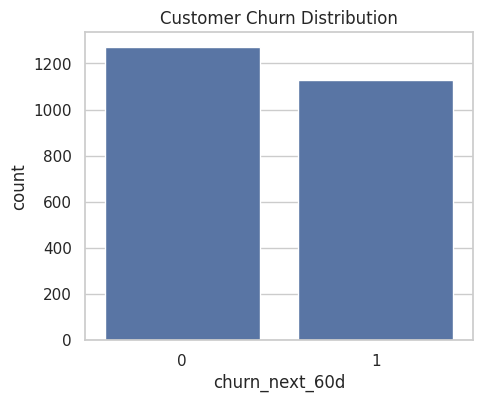

In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x='churn_next_60d', data=churn)

plt.title("Customer Churn Distribution")
plt.show()

## Initial Findings

- Dataset contains 2400 customers.
- Target variable is churn_next_60d.
- Customer_id is the primary key across datasets.
- Missing values are present in selected columns and require treatment.
- Orders table contains transaction-level data.
- Support table contains complaint history.
- Web events table contains engagement metrics.

## Data Quality **Assessment**

In [11]:
for name, df in datasets.items():
    print("="*50)
    print(name.upper())
    print("="*50)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No missing values")
    else:
        print(missing)

    print("\n")

CUSTOMERS
loyalty_tier    1386
skin_type        401
dtype: int64


ORDERS
rating    80
dtype: int64


SUPPORT
No missing values


WEB
No missing values


CHURN
No missing values


RFM
loyalty_tier    1386
dtype: int64


CAMPAIGNS
No missing values




In [12]:
for name, df in datasets.items():
    print(name)
    print("Duplicates:", df.duplicated().sum())
    print("-"*40)

customers
Duplicates: 0
----------------------------------------
orders
Duplicates: 0
----------------------------------------
support
Duplicates: 0
----------------------------------------
web
Duplicates: 0
----------------------------------------
churn
Duplicates: 0
----------------------------------------
rfm
Duplicates: 0
----------------------------------------
campaigns
Duplicates: 0
----------------------------------------


In [13]:
orders[orders['order_id'].str.contains('_DUP', na=False)].head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


In [14]:
orders['order_id'].str.contains('_DUP', na=False).sum()

np.int64(12)

## Duplicate Records

The orders dataset contains intentionally inserted duplicate-like records identified by the "_DUP" suffix in order_id.

These records simulate real-world data quality challenges and require investigation before feature engineering and modelling.

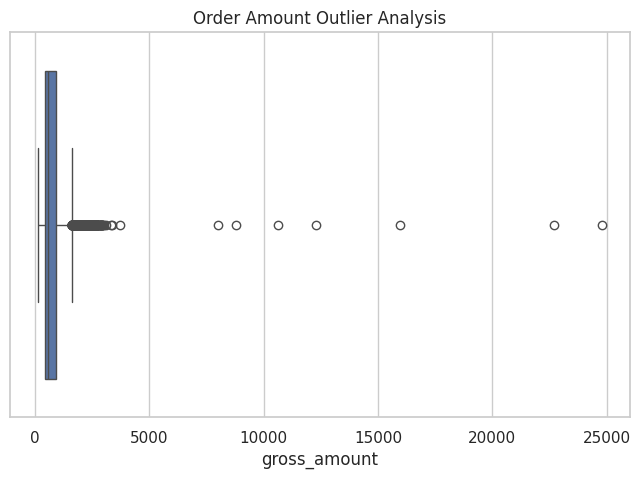

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x=orders['gross_amount'])

plt.title("Order Amount Outlier Analysis")
plt.show()

In [16]:
orders['gross_amount'].describe()

,gross_amount
count,10009.000000
mean,743.898504
std,600.564068
min,149.000000
25%,432.850000
50%,597.060000
75%,907.430000
max,24789.380000


## Outlier Assessment

The gross_amount feature contains unusually high order values.

These outliers may represent premium purchases or data anomalies.

Further investigation will be conducted before modelling.

In [17]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

snapshot_date = pd.Timestamp('2025-09-30')

post_snapshot_orders = orders[
    orders['order_date'] > snapshot_date
]

print(post_snapshot_orders.shape)

(1872, 10)


## Data Leakage Risk

Orders occurring after the snapshot date were identified.

These records must not be used for feature generation because they contain future information that would cause data leakage.

Such records will only be used to understand churn label creation.

## Missing Value Assessment

The customers dataset contains substantial missing values in the loyalty_tier feature (57.8%) and moderate missing values in skin_type (16.7%).

The orders dataset contains a small number of missing ratings (0.8%), likely due to customers not providing product feedback.

The high proportion of missing loyalty_tier values suggests that a large segment of customers may not be enrolled in the loyalty program. These missing values will be handled appropriately during preprocessing and feature engineering.

In [18]:
for name, df in datasets.items():
    print(name)
    print("Duplicates:", df.duplicated().sum())
    print("-"*50)

customers
Duplicates: 0
--------------------------------------------------
orders
Duplicates: 0
--------------------------------------------------
support
Duplicates: 0
--------------------------------------------------
web
Duplicates: 0
--------------------------------------------------
churn
Duplicates: 0
--------------------------------------------------
rfm
Duplicates: 0
--------------------------------------------------
campaigns
Duplicates: 0
--------------------------------------------------


In [19]:
orders['order_id'].str.contains('_DUP', na=False).sum()

np.int64(12)

In [20]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

snapshot_date = pd.Timestamp('2025-09-30')

post_snapshot_orders = orders[
    orders['order_date'] > snapshot_date
]

print(post_snapshot_orders.shape)

(1872, 10)


## Duplicate-like Order Records

A review of the order_id field identified 12 records containing the "_DUP" suffix.

These records were intentionally introduced to simulate real-world duplicate handling challenges.

Although no exact duplicate rows exist in the dataset, these duplicate-like records should be investigated before feature engineering and production deployment.

## Data Leakage Assessment

A total of 1,872 orders occurred after the snapshot date (2025-09-30).

These records represent future customer behaviour and must not be used for model feature generation.

Using these records would introduce data leakage and result in overly optimistic model performance estimates.

For all modeling activities, only data available on or before the snapshot date will be used.

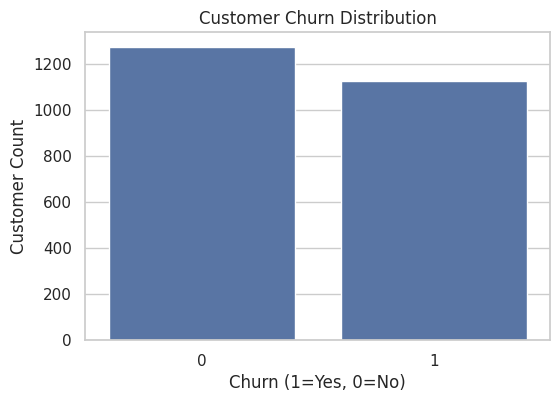

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='churn_next_60d',
    data=churn
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn (1=Yes, 0=No)")
plt.ylabel("Customer Count")

plt.show()

In [22]:
customer_churn = customers.merge(
    churn,
    on='customer_id',
    how='left'
)

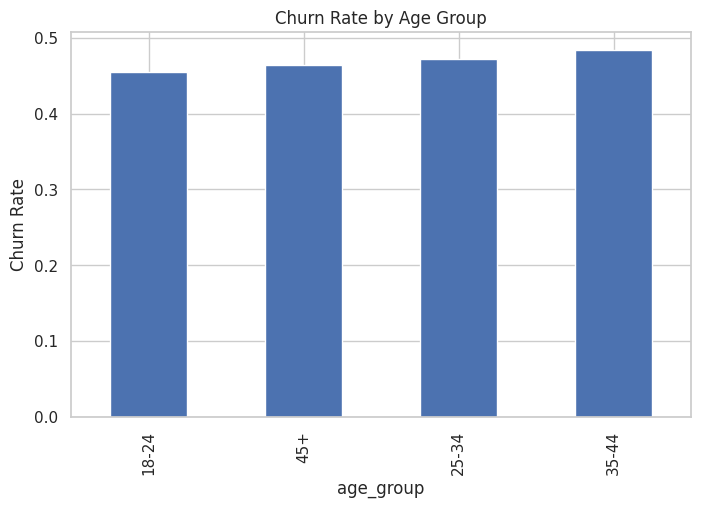

In [23]:
age_churn = pd.crosstab(
    customer_churn['age_group'],
    customer_churn['churn_next_60d'],
    normalize='index'
)

age_churn[1].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Age Group")

plt.ylabel("Churn Rate")

plt.show()

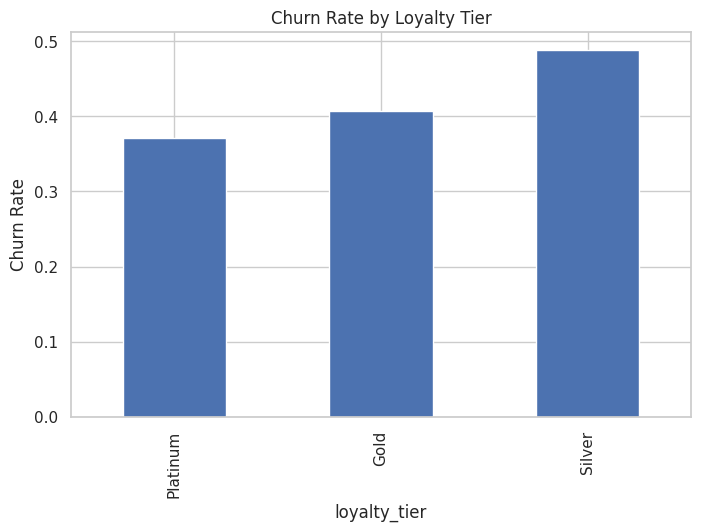

In [24]:
loyalty_churn = pd.crosstab(
    customer_churn['loyalty_tier'],
    customer_churn['churn_next_60d'],
    normalize='index'
)

loyalty_churn[1].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Loyalty Tier")

plt.ylabel("Churn Rate")

plt.show()

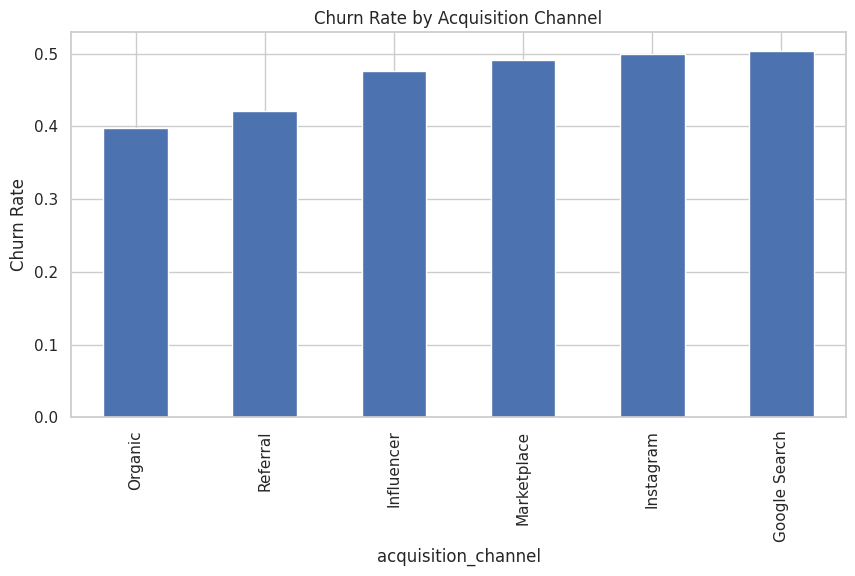

In [25]:
channel_churn = pd.crosstab(
    customer_churn['acquisition_channel'],
    customer_churn['churn_next_60d'],
    normalize='index'
)

channel_churn[1].sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Churn Rate by Acquisition Channel")
plt.ylabel("Churn Rate")
plt.show()

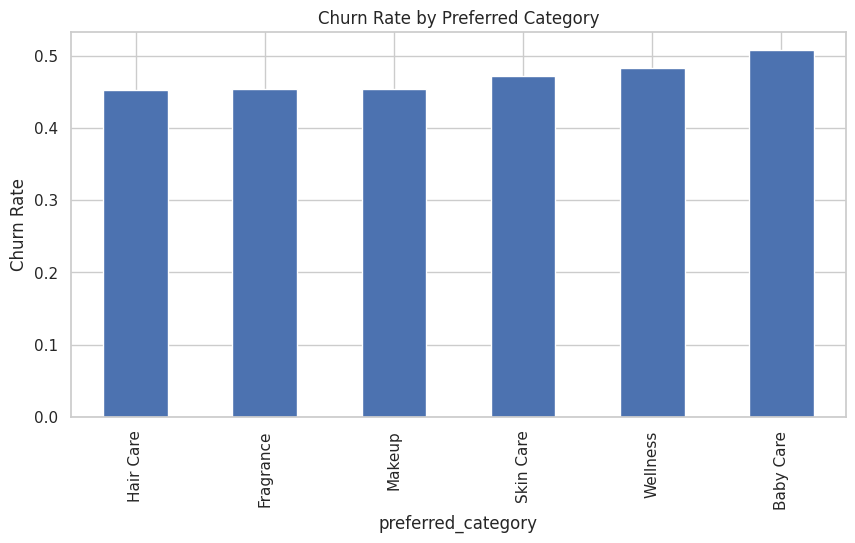

In [26]:
category_churn = pd.crosstab(
    customer_churn['preferred_category'],
    customer_churn['churn_next_60d'],
    normalize='index'
)

category_churn[1].sort_values().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Churn Rate by Preferred Category")
plt.ylabel("Churn Rate")
plt.show()

In [27]:
rfm_churn = rfm.copy()

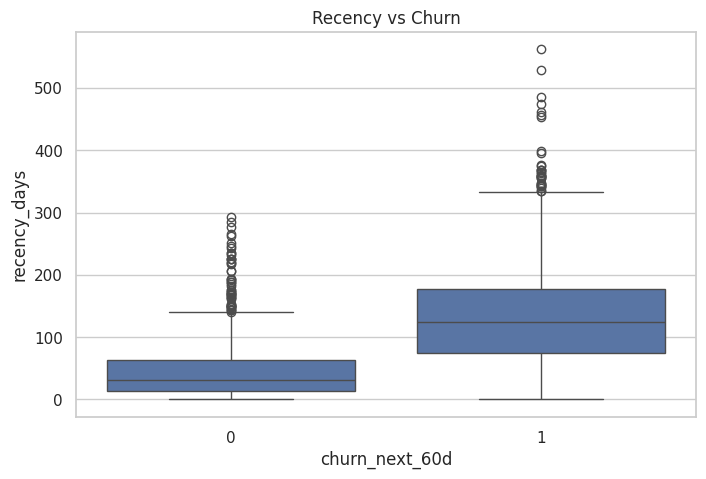

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_next_60d',
    y='recency_days',
    data=rfm_churn
)

plt.title("Recency vs Churn")
plt.show()

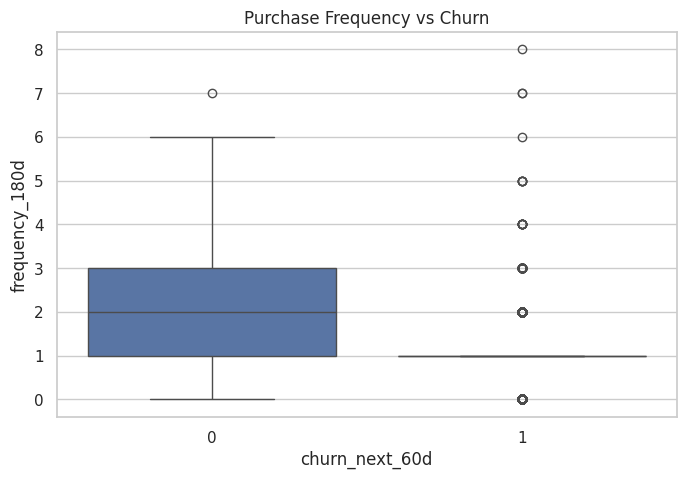

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_next_60d',
    y='frequency_180d',
    data=rfm_churn
)

plt.title("Purchase Frequency vs Churn")
plt.show()

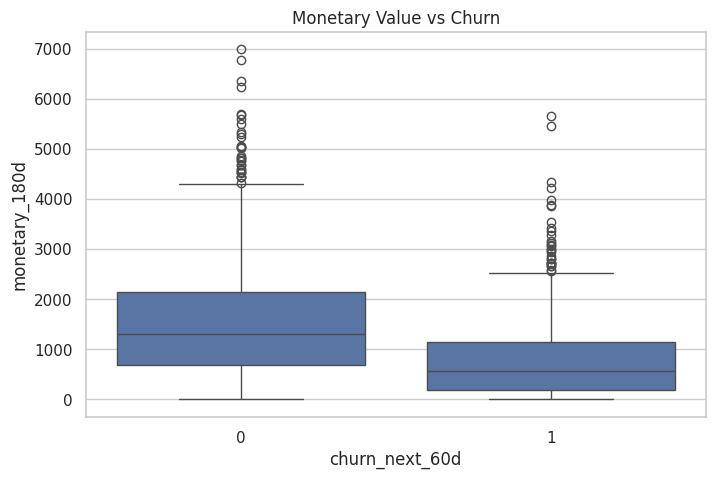

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn_next_60d',
    y='monetary_180d',
    data=rfm_churn
)

plt.title("Monetary Value vs Churn")
plt.show()

In [31]:
plt.savefig(
    "/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/churn_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig("/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/Visualizations/recency_vs_churn.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig("/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/Visualizations/Purchase Frequency vs Churn.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig("/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/Churn Rate by Acquisition Channel.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig("/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/Churn Rate by Age Group.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [38]:
plt.savefig("/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/Churn Rate by Loyalty Tier.png",
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

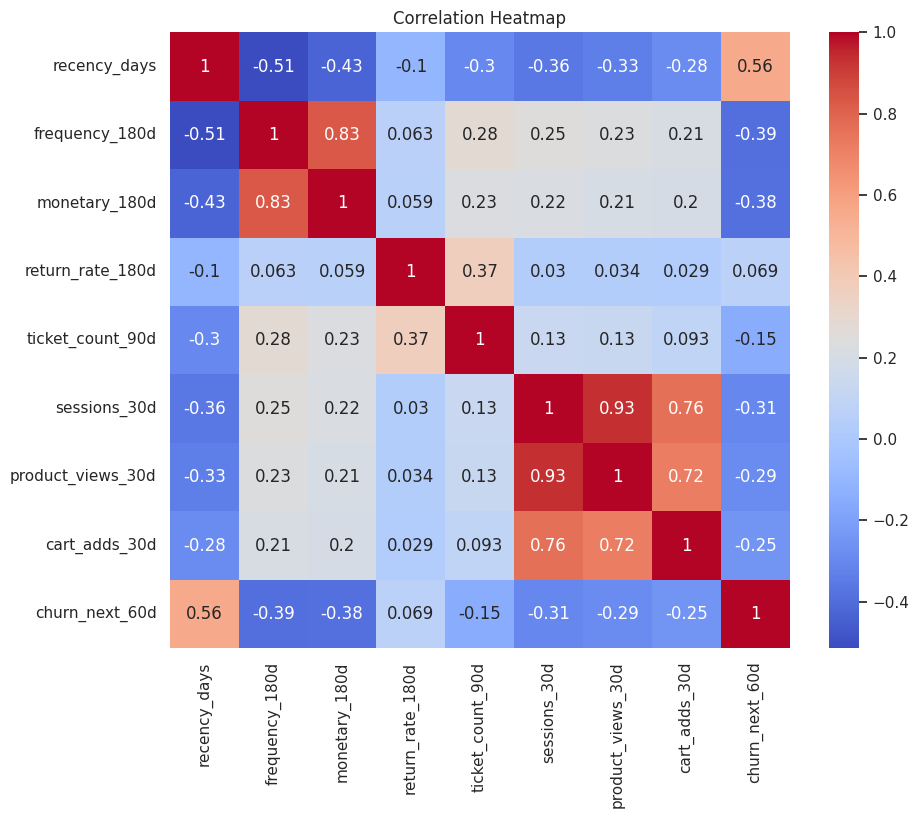

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'return_rate_180d',
    'ticket_count_90d',
    'sessions_30d',
    'product_views_30d',
    'cart_adds_30d',
    'churn_next_60d'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    rfm[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
"/content/drive/MyDrive/D2C_Churn_Capstone_JitendraBisoi/Part1_EDA_Audit/Visualizations/correlation_heatmap.png",
bbox_inches='tight'
)

plt.show()

Customers who churned have significantly higher recency values compared to retained customers.

This indicates that customers who have not made a purchase for a long period are much more likely to churn. Recency appears to be one of the strongest predictors of churn and should be prioritized in retention strategies.

Customers inactive for more than 90 days should be targeted with re-engagement campaigns, personalized offers, and reminder communications.

Retained customers tend to make purchases more frequently than churned customers.

Customers with low purchase frequency are more likely to leave the platform, indicating that frequency is an important measure of customer engagement and loyalty.

Encouraging repeat purchases through loyalty rewards and personalized recommendations may reduce churn risk.

Key Findings

1. Churn rate is approximately balanced between churned and retained customers.

2. Loyalty tier influences churn behavior, with Platinum customers exhibiting the lowest churn rates.

3. Customers acquired through Organic and Referral channels show better retention compared to paid marketing channels.

4. Recency is the strongest churn indicator; customers inactive for longer periods are significantly more likely to churn.

5. Higher purchase frequency is associated with lower churn probability.

6. Customers with higher spending levels demonstrate better retention and long-term engagement.

7. Product category preferences also influence churn, with Baby Care customers showing the highest churn rates.